In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
path_data = os.getcwd() + '/data/'
path_demand = path_data + 'output/csv/demand/'
path_loads =path_data + 'loads/'
path_generation = path_data + 'generators_profiles/'
path_losses = path_data + 'output/csv/losses/'
path_bess = path_data + 'output/csv/bess/'

In [3]:
file_loads = path_loads + 'total_loads.csv'
file_generation = path_generation + 'total_generation.csv'
file_losses = path_losses + 'Losses_NoOperation_year_CondominioDosIpes.csv'
file_demand = path_demand + 'Demand_NoOperation_year_CondominioDosIpes.csv'
file_demand_rl = path_demand + 'rl_forecasting_results.csv'
file_demand_forecasting = path_demand + 'Demand_Smoothing_bus013_year_CondominioDosIpes.csv'
bess_forecasting = path_bess + 'BessPowers_Forecasting_bus013_year_CondominioDosIpes.csv'

In [7]:
demand_values = pd.read_csv(file_demand)
demand_rl_values = pd.read_csv(file_demand_rl)
demand_values['Timestep'] = pd.to_datetime(demand_values['Timestep'])
demand_rl_values['Timestep'] = pd.to_datetime(demand_rl_values['Timestep'])
date_ini = '2012-07-07 05:30:00'
date_end = '2012-07-07 07:00:00'
time = pd.date_range(start=date_ini, end=date_end, freq='5T')
demand_values = demand_values[(demand_values['Timestep'] >= date_ini) & (demand_values['Timestep'] <= date_end)]
demand_rl_values = demand_rl_values[(demand_rl_values['Timestep'] >= date_ini) & (demand_rl_values['Timestep'] <= date_end)]



C:\Users\joao9\AppData\Local\Temp\ipykernel_24412\3825637951.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time = pd.date_range(start=date_ini, end=date_end, freq='5T')


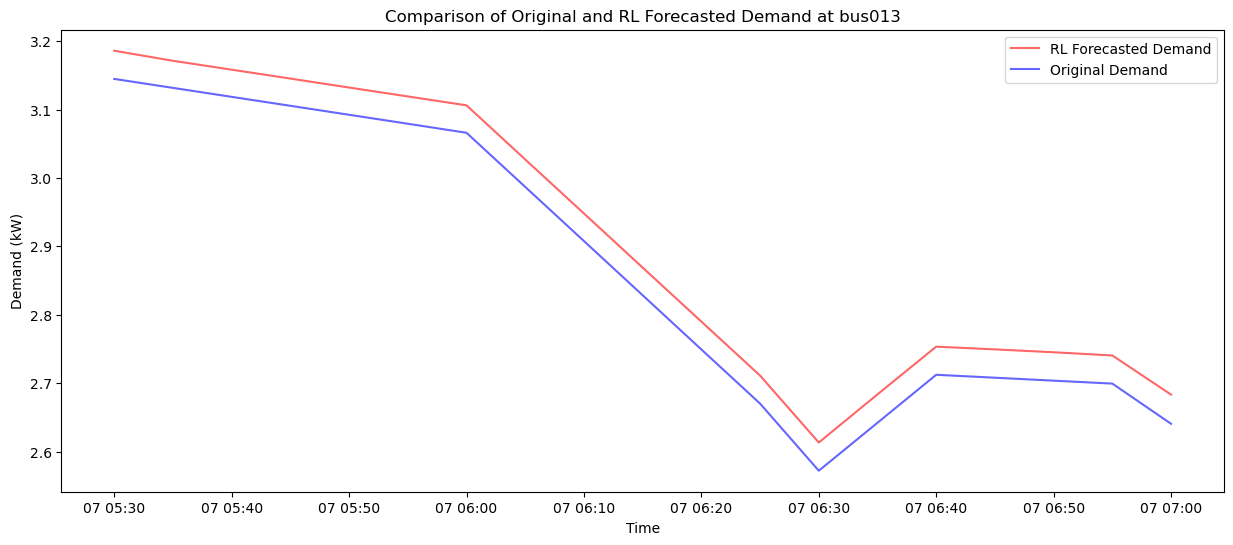

In [8]:
# plotting the demand values

plt.figure(figsize=(15, 6))
plt.plot(time, demand_rl_values['P(kW)'], label='RL Forecasted Demand', color='red', alpha=0.6)
plt.plot(time, demand_values['P(kW)'], label='Original Demand', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Demand (kW)')
plt.title('Comparison of Original and RL Forecasted Demand at bus013')
plt.legend()